In [1]:
# import libraries

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.model_selection import RandomizedSearchCV

RSEED = 50

In [2]:
# load data

train_data = pd.read_csv("../data/train_data.csv", index_col=0)     # index_col=0 is the row where the index is saved; (I saved the csv file with index=True, so it saves the index to row nr 0)
validation_data = pd.read_csv("../data/validation_data.csv", index_col=0)

In [3]:
# split into X and y again:

X_train = train_data.drop('Irrigation_Need', axis=1)
y_train = train_data['Irrigation_Need']

X_valid = validation_data.drop('Irrigation_Need', axis=1)
y_valid = validation_data['Irrigation_Need']

In [4]:
X_train.columns

Index(['Soil_pH', 'Soil_Moisture', 'Organic_Carbon', 'Electrical_Conductivity',
       'Temperature_C', 'Humidity', 'Rainfall_mm', 'Sunlight_Hours',
       'Wind_Speed_kmh', 'Field_Area_hectare', 'Previous_Irrigation_mm',
       'Soil_Type_Loamy', 'Soil_Type_Sandy', 'Soil_Type_Silt',
       'Crop_Type_Maize', 'Crop_Type_Potato', 'Crop_Type_Rice',
       'Crop_Type_Sugarcane', 'Crop_Type_Wheat', 'Crop_Growth_Stage_Harvest',
       'Crop_Growth_Stage_Sowing', 'Crop_Growth_Stage_Vegetative',
       'Season_Rabi', 'Season_Zaid', 'Irrigation_Type_Drip',
       'Irrigation_Type_Rainfed', 'Irrigation_Type_Sprinkler',
       'Water_Source_Rainwater', 'Water_Source_Reservoir',
       'Water_Source_River', 'Region_East', 'Region_North', 'Region_South',
       'Region_West', 'Mulching_Used'],
      dtype='object')

In [ ]:
# colormap for all heatmaps
from matplotlib.colors import LinearSegmentedColormap
custom_cmap = LinearSegmentedColormap.from_list(
    "gray_to_orange",
    ["#F0FFFF", "#E0E0E0", "#FFCC80", "#FF8C00", "#FE420F"]
)

# Decision Tree

In [8]:
# decision tree

# find good hyperparameters with RandomizedSearch

# see how much time it takes
import time

before = time.process_time()

# setting hyperparameters to test
param_dist = {
    "max_depth": [3, 5, 7, 10, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 5, 10, 20],
    "max_features": [None, "sqrt", "log2"]
}

dec_tree = DecisionTreeClassifier(class_weight="balanced", random_state=RSEED)

search = RandomizedSearchCV(
    dec_tree,
    param_distributions=param_dist,
    n_iter=20,  # how many random combinations of hyperparameters are tested
    scoring='f1_macro', # (F1_class0 + F1_class1 + F1_class2) / 3 (F1 score weighted would give a bigger weight to bigger classes and we don't want that here)
    cv=5,
    random_state=RSEED,
    n_jobs=-1
)

search.fit(X_train, y_train)

# find best model
best_dt = search.best_estimator_

# predictions
y_pred_train_dt = best_dt.predict(X_train)
y_pred_valid_dt = best_dt.predict(X_valid)

# measuring time
after = time.process_time()

print(after - before, 'seconds')

# print hyperparameters
print(search.best_params_)


5.953125 seconds
{'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': None, 'max_depth': 7}


F1 macro score training set: 0.958553
F1 macro score validation set: 0.957065
Classification report for decision tree on train data: 
               precision    recall  f1-score   support

           0       0.99      1.00      0.99    258942
           1       0.99      0.97      0.98    167352
           2       0.88      0.93      0.91     14706

    accuracy                           0.98    441000
   macro avg       0.95      0.97      0.96    441000
weighted avg       0.98      0.98      0.98    441000

Classification report for decision tree on validation data: 
               precision    recall  f1-score   support

           0       0.99      1.00      0.99    110975
           1       0.99      0.97      0.98     71722
           2       0.88      0.93      0.90      6303

    accuracy                           0.98    189000
   macro avg       0.95      0.96      0.96    189000
weighted avg       0.98      0.98      0.98    189000



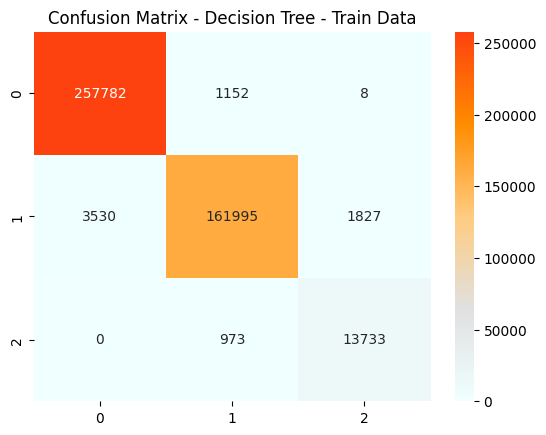

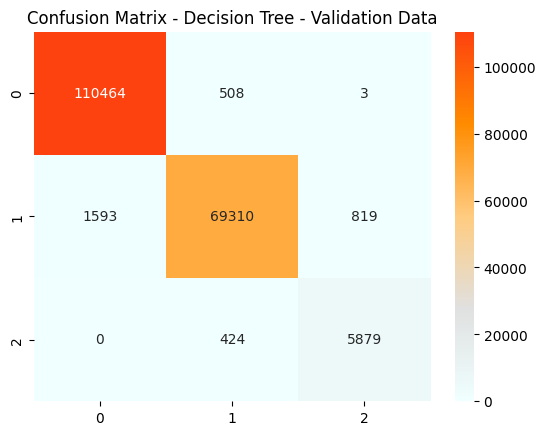

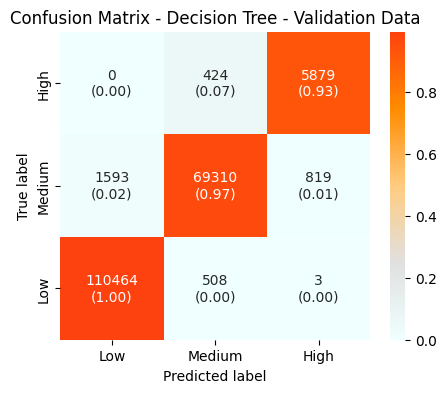

In [ ]:
# evaluation of decision tree

# printing F1 macro score only
print('F1 macro score training set:', f1_score(y_train, y_pred_train_dt, average='macro').round(6))
print('F1 macro score validation set:', f1_score(y_valid, y_pred_valid_dt, average='macro').round(6))

# classification report
print('Classification report for decision tree on train data:', '\n', classification_report(y_train, y_pred_train_dt))
print('Classification report for decision tree on validation data:', '\n', classification_report(y_valid, y_pred_valid_dt))

# confusion matrix 1
plt.figure()
cm1 = confusion_matrix(y_train, y_pred_train_dt)
sns.heatmap(cm1, cmap=custom_cmap, annot=True, fmt='d')
plt.title('Confusion Matrix - Decision Tree - Train Data')
plt.show()

# confusion matrix 2
plt.figure()
cm2 = confusion_matrix(y_valid, y_pred_valid_dt)
sns.heatmap(cm2, cmap=custom_cmap, annot=True, fmt='d')
plt.title('Confusion Matrix - Decision Tree - Validation Data')
plt.show()

###############################################################
# nicer confusion matrix 2 for presentation
cm2_norm = cm2.astype(float) / cm2.sum(axis=1, keepdims=True)

annot_dectree = np.empty_like(cm2).astype(str)

for i in range(cm2.shape[0]):
   for j in range(cm2.shape[1]):
       annot_dectree[i, j] = f"{cm2[i, j]}\n({cm2_norm[i, j]:.2f})"


# plot heatmap
fig, ax = plt.subplots(1, 1, figsize=(5, 4))

sns.heatmap(cm2_norm, cmap=custom_cmap, annot=annot_dectree, fmt="", ax=ax, yticklabels=["Low", "Medium", "High"], xticklabels=["Low", "Medium", "High"])
ax.set_title("Confusion Matrix - Decision Tree - Validation Data")
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
ax.invert_yaxis()


# Logistic Regression

In [15]:
# feature engineering for logistic regression

# train data
X_train_2 = X_train.copy()

X_train_2['Water_Input'] = X_train_2['Rainfall_mm'] + X_train_2['Previous_Irrigation_mm']

X_train_2['Evaporation'] = X_train_2['Temperature_C'] * X_train_2['Sunlight_Hours'] * X_train_2['Wind_Speed_kmh']

X_train_2['Moisture_Stress'] = X_train_2['Temperature_C'] / (X_train_2['Soil_Moisture'] + 1e-5)

X_train_2["rain_temp"] = X_train_2["Rainfall_mm"] * X_train_2["Temperature_C"]

X_train_2["humidity_temp"] = X_train_2["Humidity"] * X_train_2["Temperature_C"]


# validation data
X_valid_2 = X_valid.copy()

X_valid_2['Water_Input'] = X_valid_2['Rainfall_mm'] + X_valid_2['Previous_Irrigation_mm']

X_valid_2['Evaporation'] = X_valid_2['Temperature_C'] * X_valid_2['Sunlight_Hours'] * X_valid_2['Wind_Speed_kmh']

X_valid_2['Moisture_Stress'] = X_valid_2['Temperature_C'] / (X_valid_2['Soil_Moisture'] + 1e-5)

X_valid_2["rain_temp"] = X_valid_2["Rainfall_mm"] * X_valid_2["Temperature_C"]

X_valid_2["humidity_temp"] = X_valid_2["Humidity"] * X_valid_2["Temperature_C"]

# scale them again:

new_col = [
    'Water_Input',
    'Evaporation',
    'Moisture_Stress',
    "rain_temp",
    "humidity_temp"
]

from sklearn.preprocessing import MinMaxScaler

min_max_scaler = MinMaxScaler(feature_range=(0, 1)).set_output(transform="pandas") # 'pandas' -> output is a DataFrame

# fit ONLY on training data
min_max_scaler.fit(X=X_train_2[new_col])

# transform training and validation set
X_train_2[new_col] = min_max_scaler.transform(X=X_train_2[new_col])

X_valid_2[new_col] = min_max_scaler.transform(X=X_valid_2[new_col])

In [16]:
# logistic regression

log_reg = LogisticRegression(
    multi_class='multinomial',
    solver='lbfgs',
    max_iter=1000,
    class_weight="balanced"
)

# fit to X_train 1 and 2
log_reg.fit(X_train, y_train)

# predictions model w/o FeatEng
y_pred_train_lr_1 = log_reg.predict(X_train)
y_pred_valid_lr_1 = log_reg.predict(X_valid)


# predictions model with FeatEng
log_reg2 = LogisticRegression(
    multi_class='multinomial',
    solver='lbfgs',
    max_iter=1000,
    class_weight="balanced"
)

log_reg2.fit(X_train_2, y_train)

y_pred_train_lr_2 = log_reg2.predict(X_train_2)
y_pred_valid_lr_2 = log_reg2.predict(X_valid_2)


F1 macro score training set - w/o FeatEng: 0.743025
F1 macro score validation set - w/o FeatEng: 0.743722
F1 macro score training set - with FeatEng: 0.743825
F1 macro score validation set - with FeatEng: 0.744749
Classification report for logistic regression on train data, w/o FeatEng: 
               precision    recall  f1-score   support

           0       0.93      0.88      0.91    258942
           1       0.80      0.78      0.79    167352
           2       0.38      0.89      0.53     14706

    accuracy                           0.84    441000
   macro avg       0.71      0.85      0.74    441000
weighted avg       0.87      0.84      0.85    441000

Classification report for logistic regression on train data, with FeatEng: 
               precision    recall  f1-score   support

           0       0.93      0.88      0.91    258942
           1       0.80      0.78      0.79    167352
           2       0.38      0.89      0.53     14706

    accuracy                      

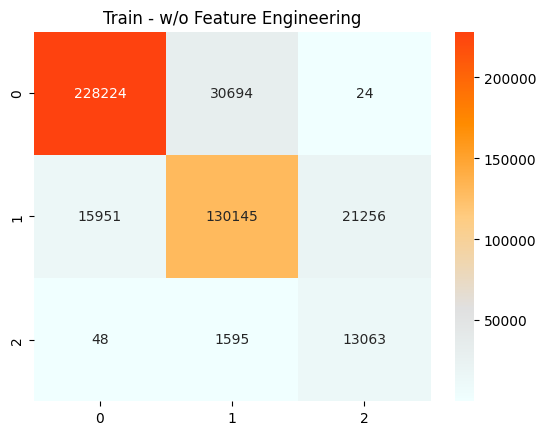

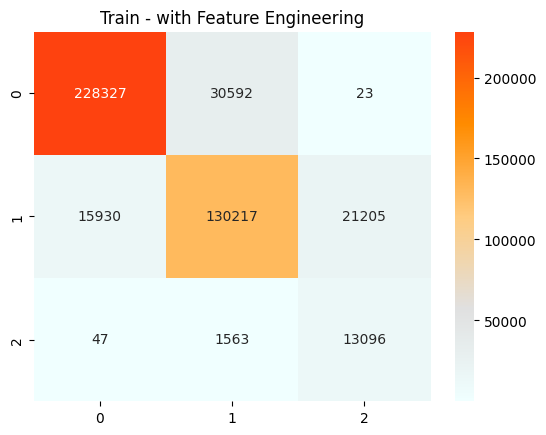

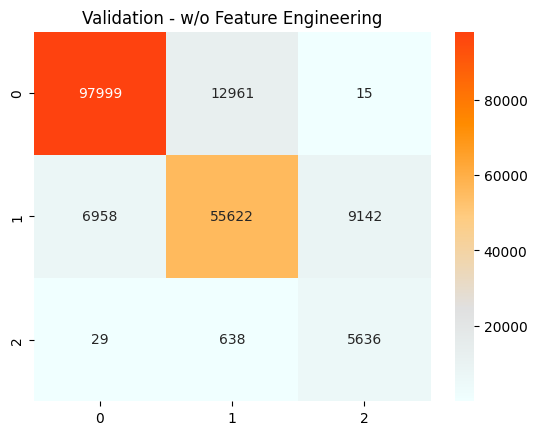

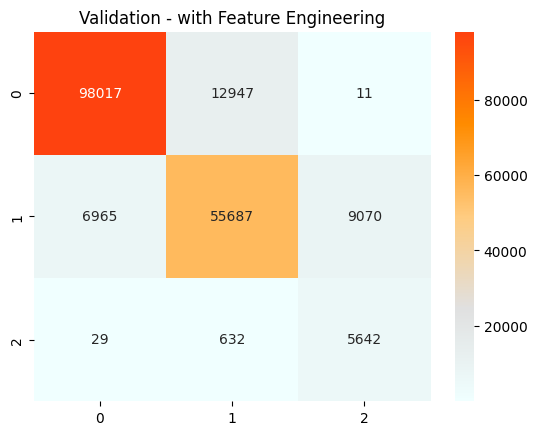

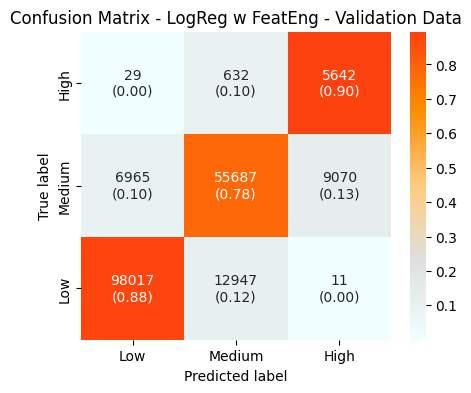

In [21]:
# evaluation of logistic regression

# print f1 macro scores
print('F1 macro score training set - w/o FeatEng:', f1_score(y_train, y_pred_train_lr_1, average='macro').round(6))
print('F1 macro score validation set - w/o FeatEng:', f1_score(y_valid, y_pred_valid_lr_1, average='macro').round(6))
print('F1 macro score training set - with FeatEng:', f1_score(y_train, y_pred_train_lr_2, average='macro').round(6))
print('F1 macro score validation set - with FeatEng:', f1_score(y_valid, y_pred_valid_lr_2, average='macro').round(6))

# classification report
print('Classification report for logistic regression on train data, w/o FeatEng:', '\n', classification_report(y_train, y_pred_train_lr_1))
print('Classification report for logistic regression on train data, with FeatEng:', '\n', classification_report(y_train, y_pred_train_lr_2))

print('Classification report for logistic regression on validation data, w/o FeatEng:', '\n', classification_report(y_valid, y_pred_valid_lr_1))
print('Classification report for logistic regression on validation data, with FeatEng:', '\n', classification_report(y_valid, y_pred_valid_lr_2))

# Confusion Matrix 1
plt.figure()
cm3 = confusion_matrix(y_train, y_pred_train_lr_1)
sns.heatmap(cm3, cmap=custom_cmap, annot=True, fmt='d')
plt.title('Train - w/o Feature Engineering')
plt.show()

# Confusion Matrix 2
plt.figure()
cm4 = confusion_matrix(y_train, y_pred_train_lr_2)
sns.heatmap(cm4, cmap=custom_cmap, annot=True, fmt='d')
plt.title('Train - with Feature Engineering')
plt.show()

# Confusion Matrix 3
plt.figure()
cm5 = confusion_matrix(y_valid, y_pred_valid_lr_1)
sns.heatmap(cm5, cmap=custom_cmap, annot=True, fmt='d')
plt.title('Validation - w/o Feature Engineering')
plt.show()

# Confusion Matrix 4
plt.figure()
cm6 = confusion_matrix(y_valid, y_pred_valid_lr_2)
sns.heatmap(cm6, cmap=custom_cmap, annot=True, fmt='d')
plt.title('Validation - with Feature Engineering')
plt.show()

################################################################
# nicer confusion matrix 4 for presentation
cm6_norm = cm6.astype(float) / cm6.sum(axis=1, keepdims=True)

annot_logreg = np.empty_like(cm6).astype(str)

for i in range(cm6.shape[0]):
   for j in range(cm6.shape[1]):
       annot_logreg[i, j] = f"{cm6[i, j]}\n({cm6_norm[i, j]:.2f})"


# plot heatmap
fig, ax = plt.subplots(1, 1, figsize=(5, 4))

sns.heatmap(cm6_norm, cmap=custom_cmap, annot=annot_logreg, fmt="", ax=ax, yticklabels=["Low", "Medium", "High"], xticklabels=["Low", "Medium", "High"])
ax.set_title("Confusion Matrix - LogReg w FeatEng - Validation Data")
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
ax.invert_yaxis()